In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
""" tiempo_seg = 60    
carga_proton = 1.602177e-19
protones_totales = (corriente_nA * 1e-9 / carga_proton) * tiempo_seg """


' tiempo_seg = 60    \ncarga_proton = 1.602177e-19\nprotones_totales = (corriente_nA * 1e-9 / carga_proton) * tiempo_seg '

In [15]:
def leer_dosis_phits_tdeposit(filename):
    dosis = []
    leyendo_tabla = False

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            linea = line.strip()

            if linea.startswith("#  z-lower") and "proton" in linea:
                leyendo_tabla = True
                continue

            if leyendo_tabla:
                if linea.startswith("#") or linea.startswith("'") or linea.startswith("ms") or linea.startswith("wt") or linea.startswith("\\") or linea.startswith("e:"):
                    leyendo_tabla = False
                    continue

                partes = linea.split()

                if len(partes) == 4:
                    try:
                        z_lower = float(partes[0])
                        z_upper = float(partes[1])
                        dose = float(partes[2])
                        rerr = float(partes[3])

                        dosis.append(dose)

                    except ValueError:
                        pass

    return np.array(dosis)


file_path = "histograma_dosis_A.out"

data_dosis = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis))
print("Dosis mínima:", np.min(data_dosis))
print("Dosis máxima:", np.max(data_dosis))
print("Primeros valores:", data_dosis[:10])

Cantidad de valores leídos: 2112
Dosis mínima: 0.0
Dosis máxima: 0.010652
Primeros valores: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [16]:
print(len(data_dosis))

2112


In [17]:
def mostrar_encabezados_phits(filename):
    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            if "dose" in linea.lower() or "r.err" in linea.lower():
                print(linea.strip())

In [18]:
file_path = "histograma_dosis_A.out"
mostrar_encabezados_phits(file_path)
data_dosis = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis))
print("Dosis mínima:", np.min(data_dosis))
print("Dosis máxima:", np.max(data_dosis))
print("Primeros valores:", data_dosis[:10])

output =  dose           # total deposit energy
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/so

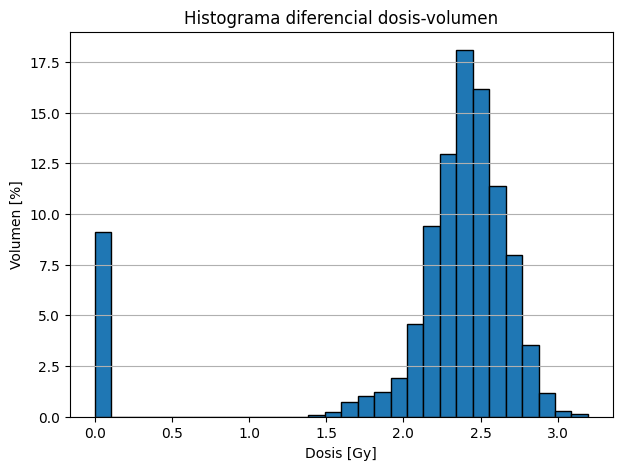

In [24]:
tiempo_seg = 300
data_dosis_fisica = data_dosis * tiempo_seg

n_voxeles = len(data_dosis_fisica)

if n_voxeles == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_voxel = 100.0 / n_voxeles

cantidad_intervalos_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=cantidad_intervalos_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))
plt.bar(
    centros_dosis,
    volumen_por_intervalo,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen")
plt.grid(True, axis="y")
plt.show()

In [13]:
# homogeneidad de la dosis en el pouch:

In [20]:
np.min(data_dosis_fisica), np.max(data_dosis_fisica), np.mean(data_dosis_fisica)

print(f"Dosis mínima en el pouch: {np.min(data_dosis_fisica):.2f} Gy")
print(f"Dosis máxima en el pouch: {np.max(data_dosis_fisica):.2f} Gy")  
print(f"Dosis media en el pouch: {np.mean(data_dosis_fisica):.2f} Gy")

Dosis mínima en el pouch: 0.00 Gy
Dosis máxima en el pouch: 3.20 Gy
Dosis media en el pouch: 2.19 Gy


In [21]:
np.std(data_dosis_fisica)/np.mean(data_dosis_fisica)
print(f"Coeficiente de variación de la dosis en el pouch: {100*np.std(data_dosis_fisica)/np.mean(data_dosis_fisica):.2f}%")

Coeficiente de variación de la dosis en el pouch: 33.33%


In [16]:
# histograma dosis-volumen acumulado

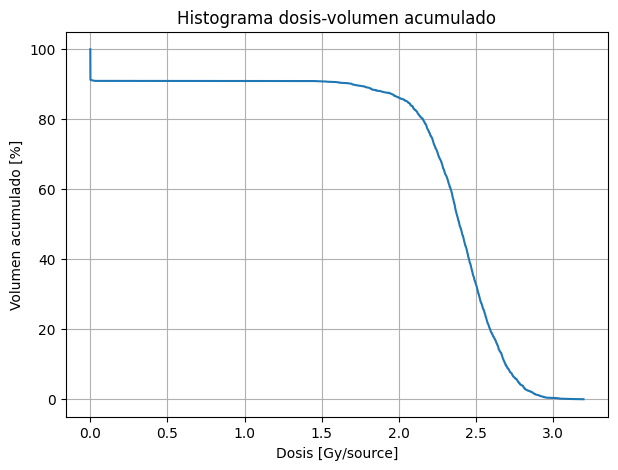

In [29]:
n_bins = len(data_dosis)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_bin = 100.0 / n_bins
volumen_total = np.ones_like(data_dosis) * volumen_por_bin

dosis_ordenada = np.sort(data_dosis)

vol_acumulado = np.array([
    np.sum(volumen_total[data_dosis >= d])
    for d in dosis_ordenada
])

plt.figure(figsize=(7, 5))
plt.plot(dosis_ordenada*tiempo_seg, vol_acumulado)


plt.xlabel("Dosis [Gy/source]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado")
plt.grid(True)
plt.show()

In [30]:
nx = 16
ny = 33
nz = 4

esperados = nx * ny * nz

print("Valores esperados:", esperados)
print("Valores leídos:", len(data_dosis))

if len(data_dosis) != esperados:
    print("Ojo: no se leyó la cantidad esperada de bins.")
else:
    print("Todo ok: se leyeron todos los bins.")

Valores esperados: 2112
Valores leídos: 2112
Todo ok: se leyeron todos los bins.


## mascara para sacarle el aire

In [19]:
# le sacamos el aire

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

In [33]:
archivo = "histograma_dosis_A.out"

xmin = -0.8
xmax = 0.8
nx = 16

ymin = -1.65
ymax = 1.65
ny = 33

zmin = 98.38
zmax = 98.58
nz = 4

x_edges = np.linspace(xmin, xmax, nx + 1)
y_edges = np.linspace(ymin, ymax, ny + 1)
z_edges = np.linspace(zmin, zmax, nz + 1)

x_centros = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centros = 0.5 * (y_edges[:-1] + y_edges[1:])
z_centros = 0.5 * (z_edges[:-1] + z_edges[1:])

print("z_centros:")
print(z_centros)

dosis = np.full((nx, ny, nz), np.nan)
err_rel = np.full((nx, ny, nz), np.nan)

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    lineas = f.readlines()

ix_actual = None
iy_actual = None
leer_tabla = False
contador_z = 0

for linea in lineas:
    m = re.search(r"ix\s*=\s*(\d+).*iy\s*=\s*(\d+)", linea)

    if m:
        ix_actual = int(m.group(1)) - 1
        iy_actual = int(m.group(2)) - 1
        leer_tabla = False
        contador_z = 0
        continue

    if linea.strip().startswith("#  z-lower"):
        leer_tabla = True
        contador_z = 0
        continue

    if leer_tabla:
        partes = linea.split()

        if len(partes) < 4:
            leer_tabla = False
            continue

        try:
            z_low = float(partes[0])
            z_up = float(partes[1])
            valor_dosis = float(partes[2])
            valor_err = float(partes[3])
        except ValueError:
            leer_tabla = False
            continue

        if ix_actual is not None and iy_actual is not None and contador_z < nz:
            dosis[ix_actual, iy_actual, contador_z] = valor_dosis
            err_rel[ix_actual, iy_actual, contador_z] = valor_err
            contador_z += 1

z_centros:
[98.405 98.455 98.505 98.555]


In [ ]:
# esta mascara dice: El voxel es pouch si el centro del voxel cae adentro del elipsoide

In [34]:
X, Y, Z = np.meshgrid(x_centros, y_centros, z_centros, indexing="ij")

x0 = 0.0
y0 = 0.0
z0 = 98.48

rx = 0.8
ry = 1.65
rz = 0.8

mascara_elipsoide = (
    ((X - x0) / rx)**2
    + ((Y - y0) / ry)**2
    + ((Z - z0) / rz)**2
) <= 1

mascara_z = (Z >= zmin) & (Z <= zmax)

mascara_pouch = mascara_elipsoide & mascara_z

print("Cantidad de voxeles dentro del pouch:", np.sum(mascara_pouch))

dosis_sin_aire = np.where(mascara_pouch, dosis, np.nan)
err_sin_aire = np.where(mascara_pouch, err_rel, np.nan)

data_dosis = dosis_sin_aire[~np.isnan(dosis_sin_aire)]

Cantidad de voxeles dentro del pouch: 1648


In [35]:
print("z_centros:")
print(z_centros)

print("Máscara pouch en la primera capa z:")
print(mascara_pouch[:, :, 0])

tiempo_seg = 300

dosis_sin_aire = np.where(mascara_pouch, dosis, np.nan)
err_sin_aire = np.where(mascara_pouch, err_rel, np.nan)

data_dosis = dosis_sin_aire[~np.isnan(dosis_sin_aire)]
data_dosis_fisica = data_dosis * tiempo_seg

print("Cantidad de voxeles dentro del pouch:", len(data_dosis))
print("Dosis mínima dentro del pouch [Gy/source]:", np.min(data_dosis))
print("Dosis máxima dentro del pouch [Gy/source]:", np.max(data_dosis))
print("Dosis mínima dentro del pouch [Gy]:", np.min(data_dosis_fisica))
print("Dosis máxima dentro del pouch [Gy]:", np.max(data_dosis_fisica))
print("Dosis media dentro del pouch [Gy]:", np.mean(data_dosis_fisica))

datos = []

for ix in range(nx):
    for iy in range(ny):
        for iz in range(nz):
            if mascara_pouch[ix, iy, iz]:
                datos.append([
                    ix + 1,
                    iy + 1,
                    iz + 1,
                    x_centros[ix],
                    y_centros[iy],
                    z_centros[iz],
                    dosis[ix, iy, iz],
                    dosis[ix, iy, iz] * tiempo_seg,
                    err_rel[ix, iy, iz]
                ])

df_pouch = pd.DataFrame(
    datos,
    columns=[
        "ix", "iy", "iz",
        "x", "y", "z",
        "dosis_Gy_source",
        "dosis_Gy",
        "err_rel"
    ]
)

df_pouch.head()

z_centros:
[98.405 98.455 98.505 98.555]
Máscara pouch en la primera capa z:
[[False False False False False False False False False False False  True
   True  True  True  True  True  True  True  True  True  True False False
  False False False False False False False False False]
 [False False False False False False False  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True False False False False False False False]
 [False False False False False  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True False False False False False]
 [False False False  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True False False False]
 [False False  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  Tr

,ix,iy,iz,x,y,z,dosis_Gy_source,dosis_Gy,err_rel
0,1,12,1,-0.75,-0.5,98.405,0.008482,2.54457,0.0775
1,1,12,2,-0.75,-0.5,98.455,0.009293,2.78790,0.0794
2,1,12,3,-0.75,-0.5,98.505,0.008433,2.53002,0.0870
3,1,12,4,-0.75,-0.5,98.555,0.008267,2.48016,0.0971
4,1,13,1,-0.75,-0.4,98.405,0.008478,2.54328,0.0785


In [36]:
print(df_pouch.groupby("iz").size())

print(df_pouch[["iz", "z"]].drop_duplicates().sort_values("iz"))

iz
1    412
2    412
3    412
4    412
dtype: int64
   iz       z
0   1  98.405
1   2  98.455
2   3  98.505
3   4  98.555


Es decir, tenemos 4 capas con 128 voxeles cada capa, perf

iz = 1 → z = 98.405 → 128 vóxeles

iz = 2 → z = 98.455 → 128 vóxeles

iz = 3 → z = 98.505 → 128 vóxeles

iz = 4 → z = 98.555 → 128 vóxeles

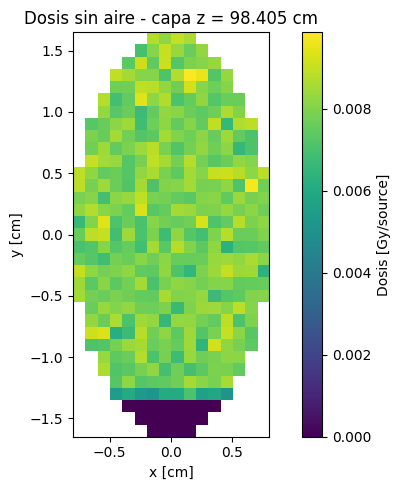

In [37]:
iz = 0

plt.figure(figsize=(7, 5))

plt.imshow(
    dosis_sin_aire[:, :, iz].T,
    origin="lower",
    extent=[xmin, xmax, ymin, ymax],
    aspect="equal"
)

plt.colorbar(label="Dosis [Gy/source]")
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title(f"Dosis sin aire - capa z = {z_centros[iz]:.3f} cm")
plt.tight_layout()
plt.show()

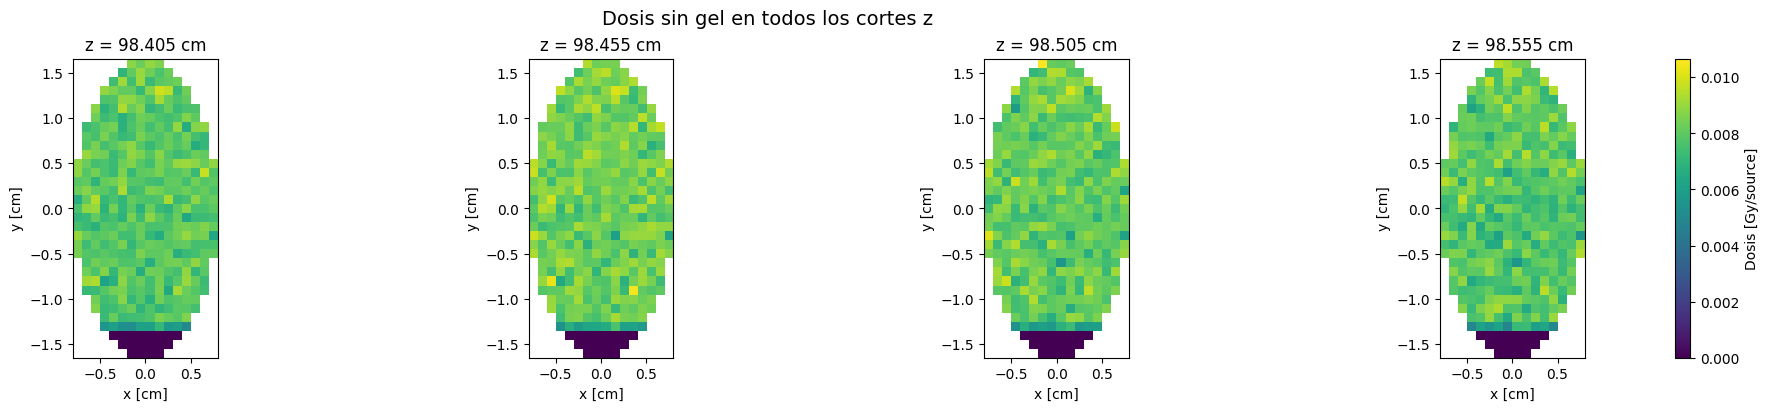

In [39]:
fig, axes = plt.subplots(1, nz, figsize=(5 * nz, 4), constrained_layout=True)

if nz == 1:
    axes = [axes]

vmin = np.nanmin(dosis_sin_aire)
vmax = np.nanmax(dosis_sin_aire)

for iz in range(nz):
    im = axes[iz].imshow(
        dosis_sin_aire[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[iz].set_xlabel("x [cm]")
    axes[iz].set_ylabel("y [cm]")
    axes[iz].set_title(f"z = {z_centros[iz]:.3f} cm")

fig.colorbar(im, ax=axes, label="Dosis [Gy/source]")

plt.suptitle("Dosis sin gel en todos los cortes z", fontsize=14)
plt.show()

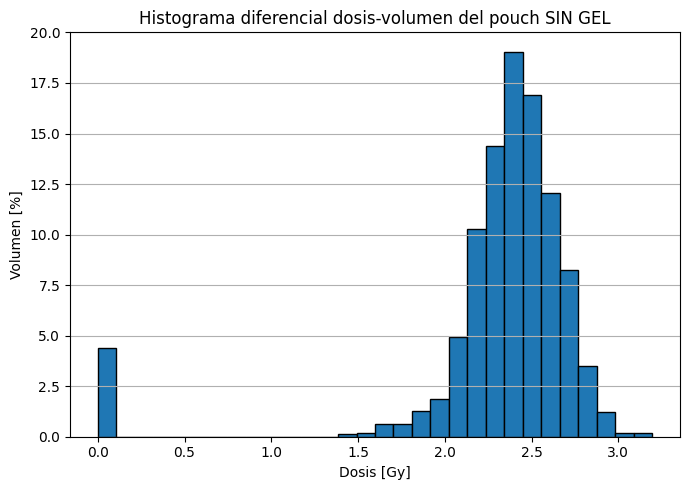

In [43]:
n_voxeles = len(data_dosis_fisica)

if n_voxeles == 0:
    raise ValueError("No hay voxeles dentro del pouch. Revisá la máscara y los límites de z.")

volumen_por_voxel = 100.0 / n_voxeles

bins_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))

plt.bar(
    centros_dosis,
    volumen_por_intervalo,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen del pouch SIN GEL")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [41]:
np.min(data_dosis_fisica), np.max(data_dosis_fisica), np.mean(data_dosis_fisica)
print(f"Dosis mínima en el pouch: {np.min(data_dosis_fisica):.2f} Gy")
print(f"Dosis máxima en el pouch: {np.max(data_dosis_fisica):.2f} Gy")
print(f"Dosis media en el pouch: {np.mean(data_dosis_fisica):.2f} Gy")

Dosis mínima en el pouch: 0.00 Gy
Dosis máxima en el pouch: 3.20 Gy
Dosis media en el pouch: 2.31 Gy


In [42]:
np.std(data_dosis_fisica)/np.mean(data_dosis_fisica)
print(f"Coeficiente de variación de la dosis en el pouch: {100*np.std(data_dosis_fisica)/np.mean(data_dosis_fisica):.2f}%")

Coeficiente de variación de la dosis en el pouch: 23.56%


## sacamos los valores extremos

In [46]:
iy_sacar = [0, 1, 2, 3]

dosis_sin_aire[:, iy_sacar, :] = np.nan
err_sin_aire[:, iy_sacar, :] = np.nan

vmin = np.nanmin(dosis_sin_aire)
vmax = np.nanmax(dosis_sin_aire)

data_dosis = dosis_sin_aire[np.isfinite(dosis_sin_aire)]
data_dosis_fisica = data_dosis * tiempo_seg

print("Centros y eliminados [cm]:", y_centros[iy_sacar])
print("Cantidad de vóxeles usados:", len(data_dosis))

Centros y eliminados [cm]: [-1.6 -1.5 -1.4 -1.3]
Cantidad de vóxeles usados: 1536


In [50]:
n_voxeles = len(data_dosis_fisica)

if n_voxeles == 0:
    raise ValueError("No hay vóxeles dentro del pouch final.")

print("Cantidad de vóxeles usados:", n_voxeles)

Cantidad de vóxeles usados: 1536


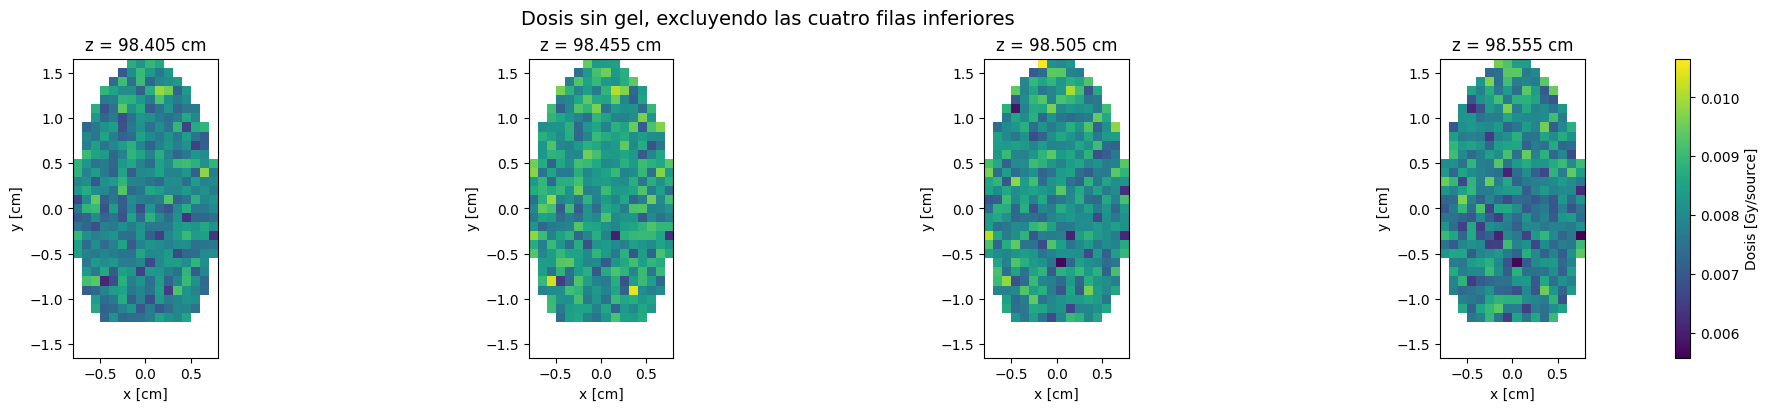

In [51]:
fig, axes = plt.subplots(
    1,
    nz,
    figsize=(5 * nz, 4),
    constrained_layout=True
)

if nz == 1:
    axes = [axes]

for iz in range(nz):
    im = axes[iz].imshow(
        dosis_sin_aire[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[iz].set_xlabel("x [cm]")
    axes[iz].set_ylabel("y [cm]")
    axes[iz].set_title(f"z = {z_centros[iz]:.3f} cm")

fig.colorbar(im, ax=axes, label="Dosis [Gy/source]")

plt.suptitle(
    "Dosis sin gel, excluyendo las cuatro filas inferiores",
    fontsize=14
)

plt.show()

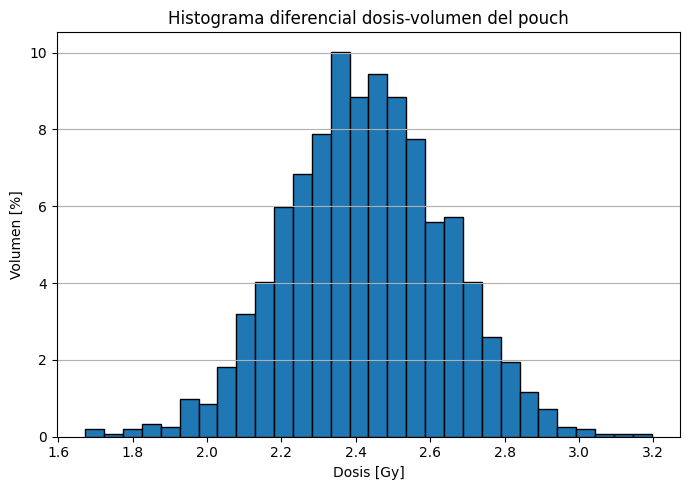

In [52]:
bins_dosis = 30
volumen_por_voxel = 100.0 / n_voxeles

volumen_diferencial, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))

plt.bar(
    centros_dosis,
    volumen_diferencial,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen del pouch")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

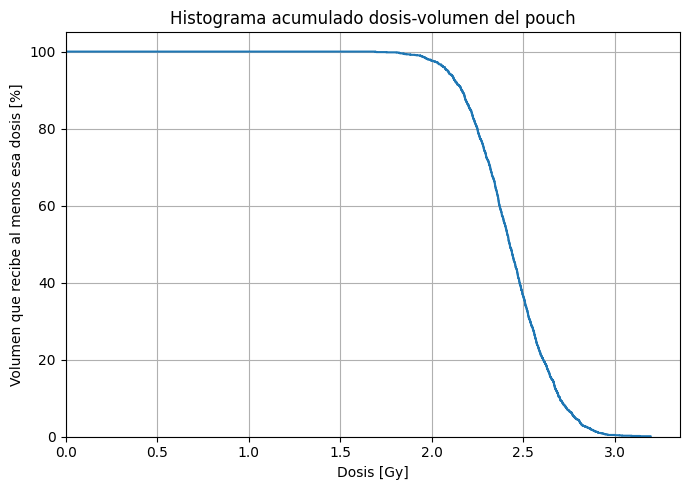

In [53]:
dosis_ordenada = np.sort(data_dosis_fisica)

volumen_acumulado = (
    100.0
    * (n_voxeles - np.arange(n_voxeles))
    / n_voxeles
)

dosis_grafico = np.insert(dosis_ordenada, 0, 0.0)
volumen_grafico = np.insert(volumen_acumulado, 0, 100.0)

plt.figure(figsize=(7, 5))

plt.step(
    dosis_grafico,
    volumen_grafico,
    where="post"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen que recibe al menos esa dosis [%]")
plt.title("Histograma acumulado dosis-volumen del pouch")
plt.grid(True)
plt.xlim(left=0)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

In [54]:
media = np.mean(data_dosis_fisica)
desvio = np.std(data_dosis_fisica)
cv = 100 * desvio / media

print("Dosis mínima [Gy]:", np.min(data_dosis_fisica))
print("Dosis máxima [Gy]:", np.max(data_dosis_fisica))
print("Dosis media [Gy]:", media)
print("Desvío estándar [Gy]:", desvio)
print("Coeficiente de variación [%]:", cv)

Dosis mínima [Gy]: 1.6725
Dosis máxima [Gy]: 3.1956
Dosis media [Gy]: 2.42700474609375
Desvío estándar [Gy]: 0.21375465461017137
Coeficiente de variación [%]: 8.80734390627823


### por capas

las capas son:

capa 1: 98.115 → 98.165 cm, centro 98.140 cm

capa 2: 98.165 → 98.215 cm, centro 98.190 cm

capa 3: 98.215 → 98.265 cm, centro 98.240 cm

capa 4: 98.265 → 98.315 cm, centro 98.290 cm

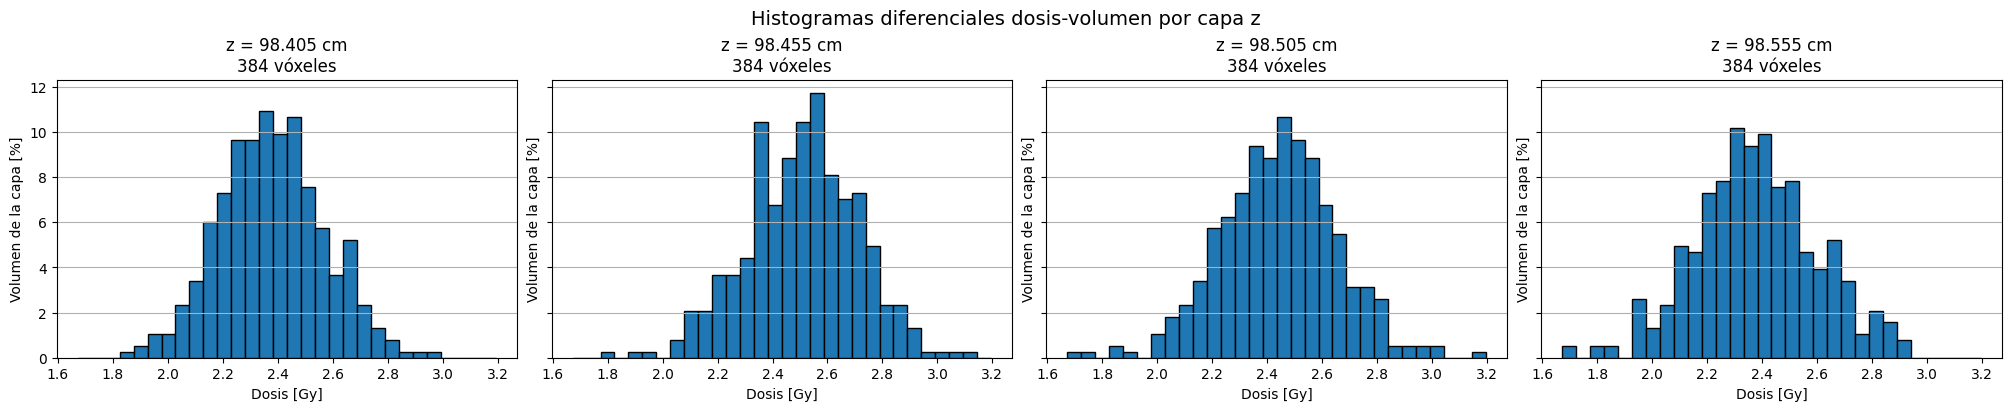

In [55]:
bins_dosis = 30

data_global = dosis_sin_aire[np.isfinite(dosis_sin_aire)] * tiempo_seg

dosis_min_global = np.min(data_global)
dosis_max_global = np.max(data_global)

bordes_comunes = np.linspace(
    dosis_min_global,
    dosis_max_global,
    bins_dosis + 1
)

fig, axes = plt.subplots(
    1,
    nz,
    figsize=(5 * nz, 4),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

if nz == 1:
    axes = [axes]

for iz in range(nz):

    data_capa = dosis_sin_aire[:, :, iz]
    data_capa = data_capa[np.isfinite(data_capa)]
    data_capa_fisica = data_capa * tiempo_seg

    n_voxeles_capa = len(data_capa_fisica)

    if n_voxeles_capa == 0:
        axes[iz].set_title(
            f"z = {z_centros[iz]:.3f} cm\nsin vóxeles"
        )
        axes[iz].axis("off")
        continue

    volumen_por_voxel = 100.0 / n_voxeles_capa

    volumen_por_intervalo, bordes_dosis = np.histogram(
        data_capa_fisica,
        bins=bordes_comunes,
        weights=np.full(
            n_voxeles_capa,
            volumen_por_voxel
        )
    )

    centros_dosis = 0.5 * (
        bordes_dosis[:-1] + bordes_dosis[1:]
    )

    anchos = np.diff(bordes_dosis)

    axes[iz].bar(
        centros_dosis,
        volumen_por_intervalo,
        width=anchos,
        align="center",
        edgecolor="black"
    )

    axes[iz].set_xlabel("Dosis [Gy]")
    axes[iz].set_ylabel("Volumen de la capa [%]")
    axes[iz].set_title(
        f"z = {z_centros[iz]:.3f} cm\n"
        f"{n_voxeles_capa} vóxeles"
    )
    axes[iz].grid(True, axis="y")

plt.suptitle(
    "Histogramas diferenciales dosis-volumen por capa z",
    fontsize=14
)

plt.show()

In [56]:
for iz in range(nz):

    data_capa = dosis_sin_aire[:, :, iz]
    data_capa = data_capa[np.isfinite(data_capa)]
    data_capa_fisica = data_capa * tiempo_seg

    print(
        f"Capa {iz + 1}: "
        f"z = {z_edges[iz]:.3f} a {z_edges[iz + 1]:.3f} cm "
        f"(centro = {z_centros[iz]:.3f} cm)"
    )

    n_voxeles_capa = len(data_capa_fisica)

    if n_voxeles_capa == 0:
        print("No hay vóxeles dentro del pouch en esta capa.")
        print()
        continue

    dosis_minima = np.min(data_capa_fisica)
    dosis_maxima = np.max(data_capa_fisica)
    dosis_media = np.mean(data_capa_fisica)
    dosis_std = np.std(data_capa_fisica)

    if dosis_media != 0:
        cv = 100.0 * dosis_std / dosis_media
    else:
        cv = np.nan

    print(f"Cantidad de vóxeles usados: {n_voxeles_capa}")
    print(f"Dosis mínima [Gy]: {dosis_minima:.4f}")
    print(f"Dosis máxima [Gy]: {dosis_maxima:.4f}")
    print(f"Dosis media [Gy]: {dosis_media:.4f}")
    print(f"Desvío estándar [Gy]: {dosis_std:.4f}")
    print(f"Coeficiente de variación [%]: {cv:.2f}")
    print()

Capa 1: z = 98.380 a 98.430 cm (centro = 98.405 cm)
Cantidad de vóxeles usados: 384
Dosis mínima [Gy]: 1.8503
Dosis máxima [Gy]: 2.9604
Dosis media [Gy]: 2.3790
Desvío estándar [Gy]: 0.1892
Coeficiente de variación [%]: 7.95

Capa 2: z = 98.430 a 98.480 cm (centro = 98.455 cm)
Cantidad de vóxeles usados: 384
Dosis mínima [Gy]: 1.8074
Dosis máxima [Gy]: 3.1362
Dosis media [Gy]: 2.5086
Desvío estándar [Gy]: 0.2029
Coeficiente de variación [%]: 8.09

Capa 3: z = 98.480 a 98.530 cm (centro = 98.505 cm)
Cantidad de vóxeles usados: 384
Dosis mínima [Gy]: 1.6958
Dosis máxima [Gy]: 3.1956
Dosis media [Gy]: 2.4427
Desvío estándar [Gy]: 0.2122
Coeficiente de variación [%]: 8.69

Capa 4: z = 98.530 a 98.580 cm (centro = 98.555 cm)
Cantidad de vóxeles usados: 384
Dosis mínima [Gy]: 1.6725
Dosis máxima [Gy]: 2.9070
Dosis media [Gy]: 2.3777
Desvío estándar [Gy]: 0.2217
Coeficiente de variación [%]: 9.33

